In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("/content/Global_Superstore2.xlsx")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [5]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
City,0
State,0


In [6]:
num_cols = df.select_dtypes(include=["number"]).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [8]:
cat_cols = df.select_dtypes(include=["object"]).columns

df[cat_cols] = df[cat_cols].fillna("Unknown")

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

In [11]:
df["Customer Name"] = df["Customer Name"].str.title()

df["Region"] = df["Region"].str.title()

df["Country"] = df["Country"].str.title()

In [12]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

/tmp/ipykernel_3890/13081262.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order Date"] = pd.to_datetime(df["Order Date"])


In [14]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
City,object
State,object


In [15]:
df.to_excel("Cleaned_Global_Superstore.xlsx", index=False)

In [16]:
summary = pd.DataFrame({
    "Metric":[
        "Total Rows",
        "Total Columns",
        "Missing Values",
        "Duplicate Rows",
        "Total Sales",
        "Total Profit"
    ],
    "Value":[
        len(df),
        len(df.columns),
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df["Sales"].sum(),
        df["Profit"].sum()
    ]
})

summary

,Metric,Value
0,Total Rows,5.129000e+04
1,Total Columns,2.400000e+01
2,Missing Values,0.000000e+00
3,Duplicate Rows,0.000000e+00
4,Total Sales,1.264250e+07
5,Total Profit,1.467457e+06


In [18]:
summary.to_excel("Automation_Report.xlsx", index=False)

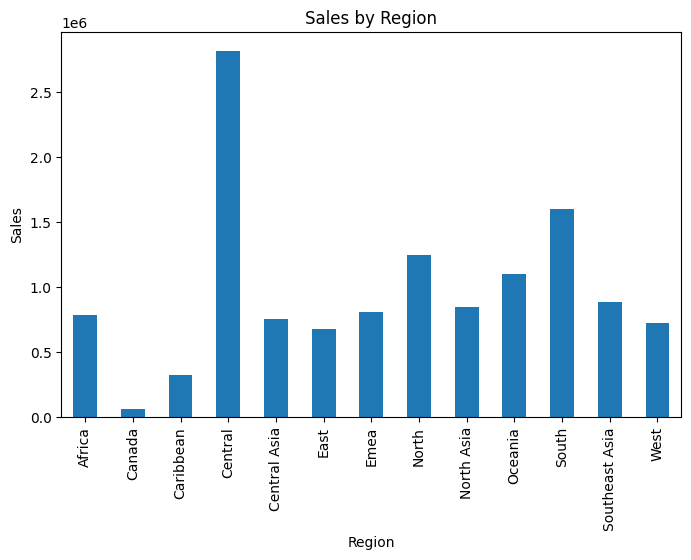

In [19]:
sales_region = df.groupby("Region")["Sales"].sum()

sales_region.plot(kind="bar", figsize=(8,5))

plt.title("Sales by Region")

plt.xlabel("Region")

plt.ylabel("Sales")

plt.show()

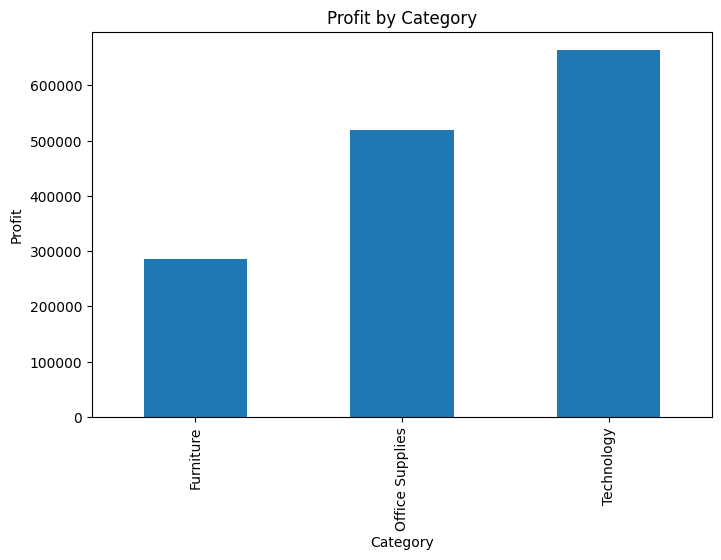

In [20]:
profit_category = df.groupby("Category")["Profit"].sum()

profit_category.plot(kind="bar", figsize=(8,5))

plt.title("Profit by Category")

plt.xlabel("Category")

plt.ylabel("Profit")

plt.show()

/tmp/ipykernel_3890/4050915890.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.groupby(pd.Grouper(key="Order Date",freq="M"))["Sales"].sum()


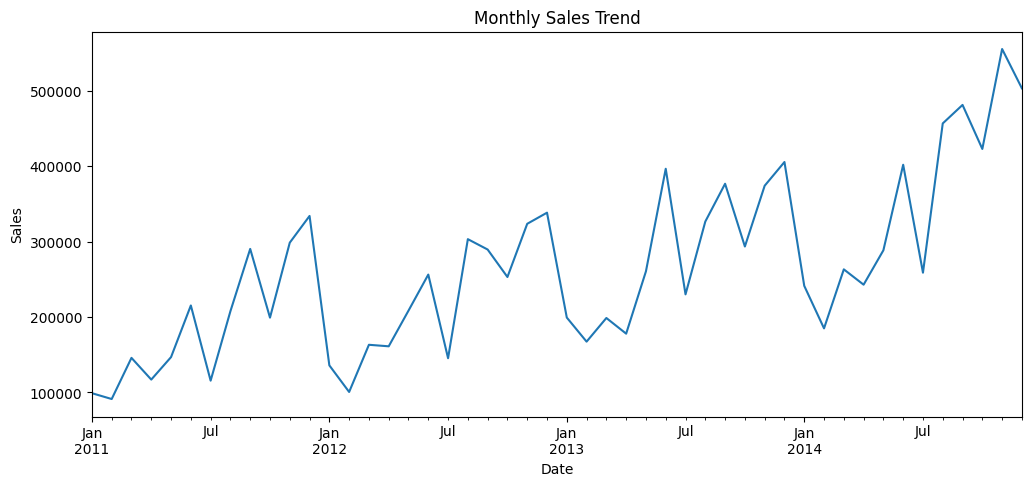

In [21]:
monthly = df.groupby(pd.Grouper(key="Order Date",freq="M"))["Sales"].sum()

monthly.plot(figsize=(12,5))

plt.title("Monthly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [22]:
from google.colab import files

files.download("Cleaned_Global_Superstore.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
files.download("Automation_Report.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>